# Visualisation

In [1]:
from tslearn.datasets import UCR_UEA_datasets
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

Shape of the dataset:
X_train : (2459, 36, 6) (samples, time steps, channels)
X_test  : (2466, 36, 6)
Number of classes : 14
Channels per series : 6 (Bands u, g, r, i, z, y)
Time steps : 36
Class 15 : 123 samples (5.0%)
Class 16 : 270 samples (11.0%)
Class 42 : 381 samples (15.5%)
Class 52 : 62 samples (2.5%)
Class 53 : 7 samples (0.3%)
Class 6 : 34 samples (1.4%)
Class 62 : 153 samples (6.2%)
Class 64 : 23 samples (0.9%)
Class 65 : 313 samples (12.7%)
Class 67 : 68 samples (2.8%)
Class 88 : 120 samples (4.9%)
Class 90 : 777 samples (31.6%)
Class 92 : 77 samples (3.1%)
Class 95 : 51 samples (2.1%)


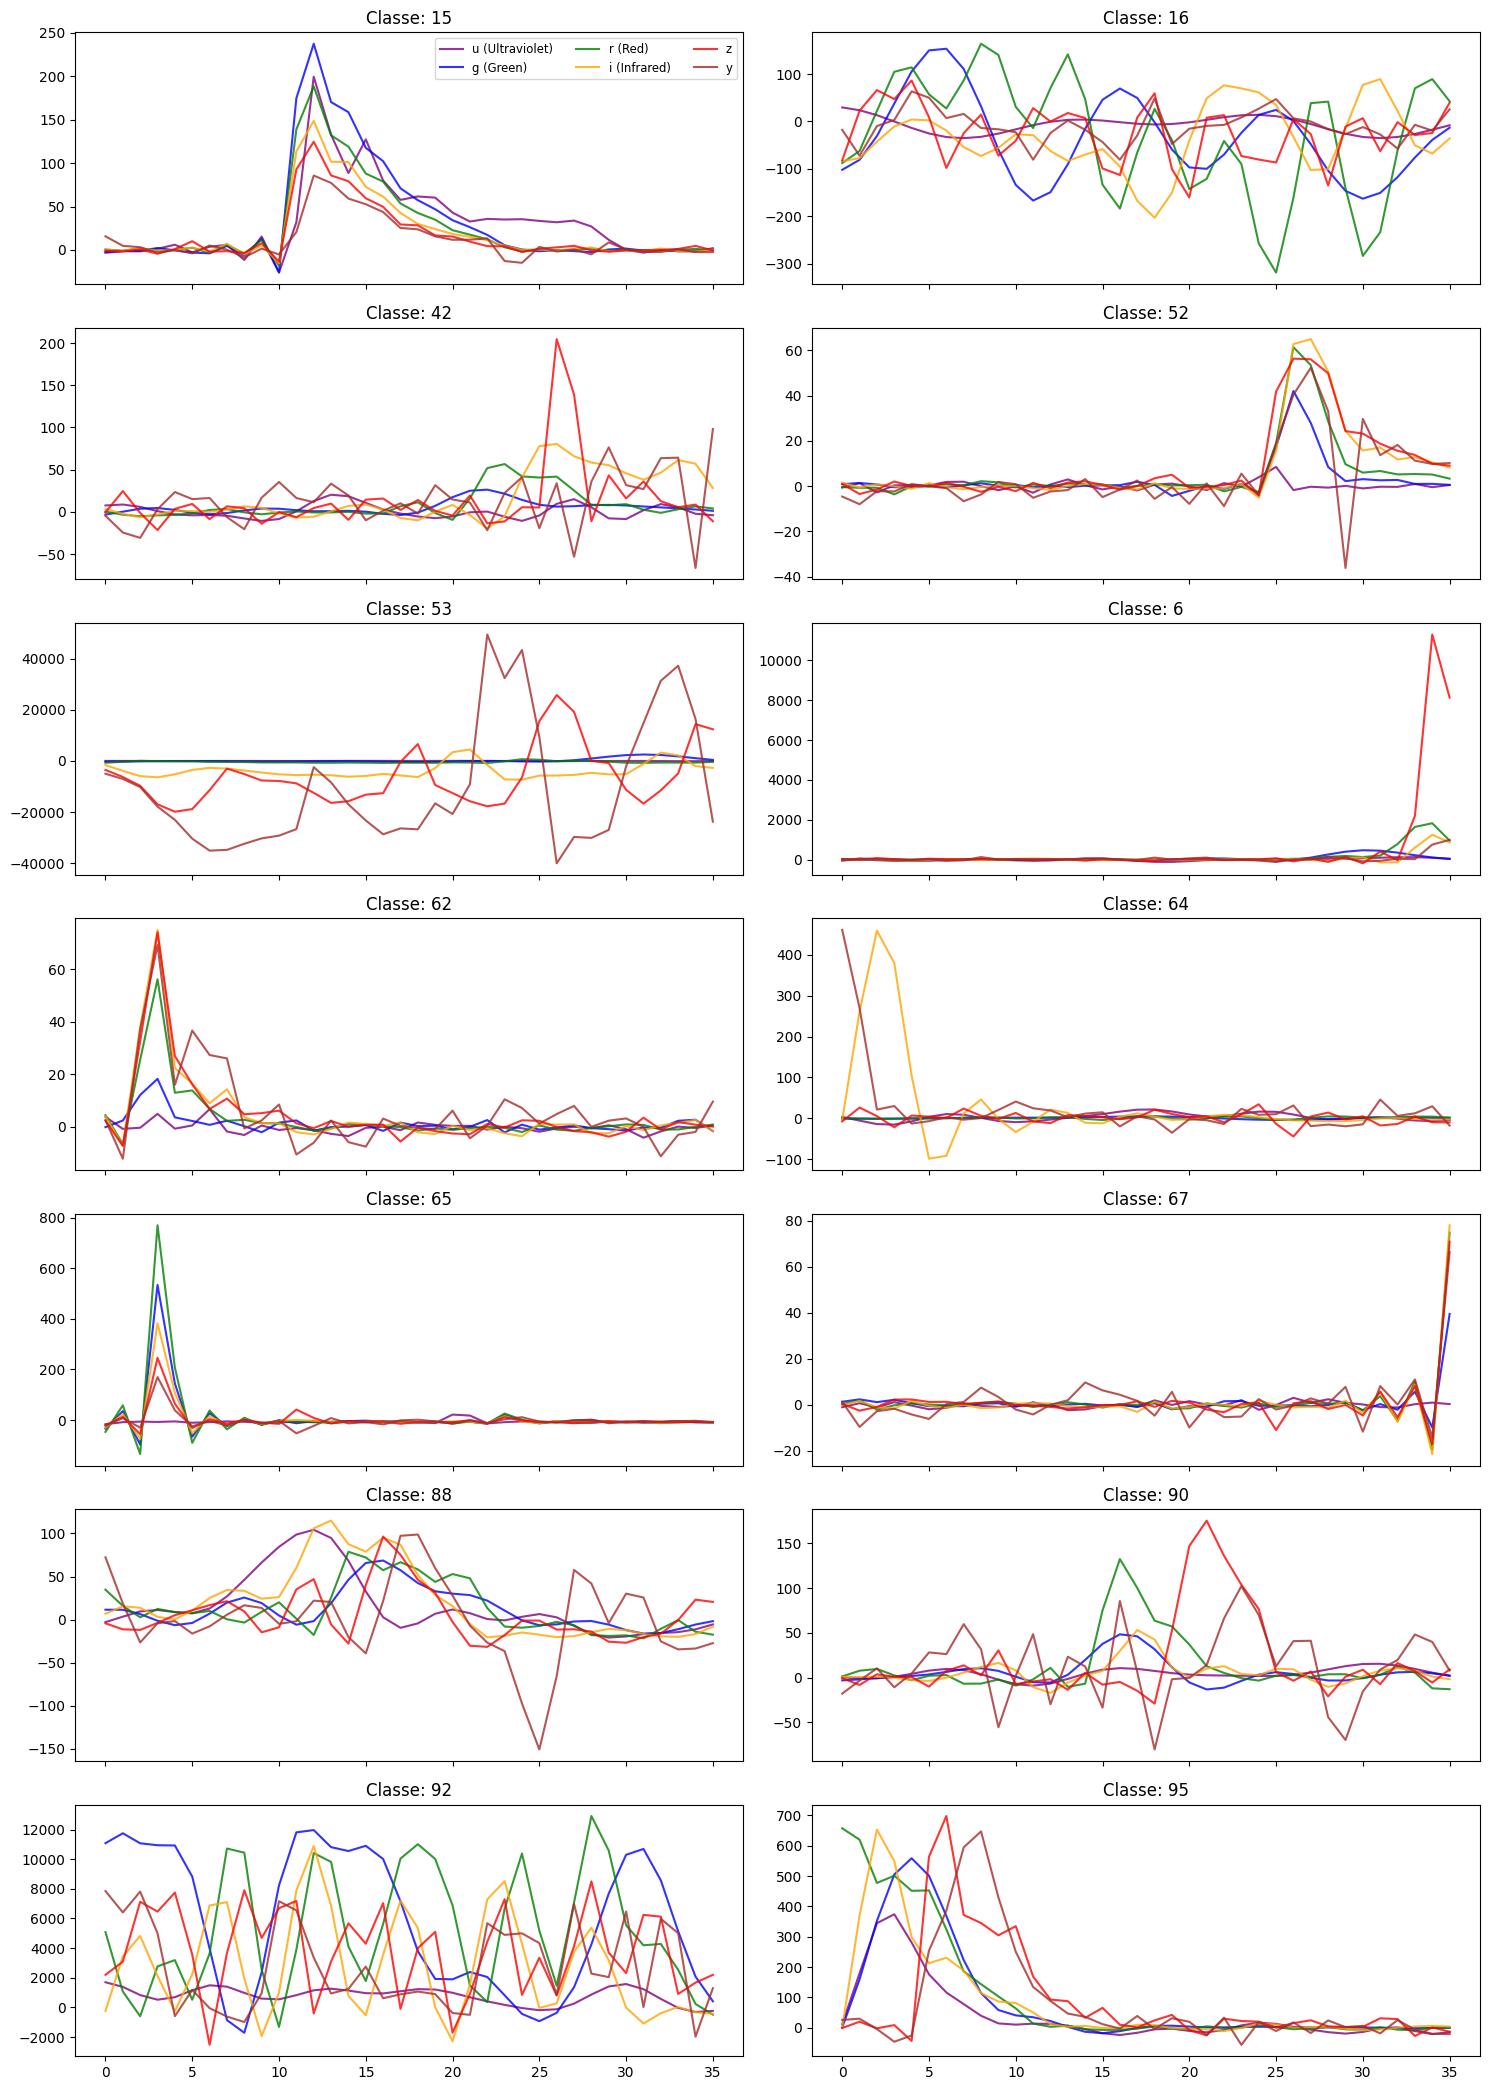

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Simple statistics
classes, counts = np.unique(y_train, return_counts=True)
n_classes = len(classes)
n_timestamps = X_train.shape[1]
n_channels = X_train.shape[2]

print("Shape of the dataset:")
print(f"X_train : {X_train.shape} (samples, time steps, channels)")
print(f"X_test  : {X_test.shape}")
print(f"Number of classes : {n_classes}")
print(f"Channels per series : {n_channels} (Bands u, g, r, i, z, y)")
print(f"Time steps : {n_timestamps}")


for c, count in zip(classes, counts):
    print(f"Class {c} : {count} samples ({count/len(y_train)*100:.1f}%)")

# Visualisation for the first sample of each class
channel_names = ['u (Ultraviolet)', 'g (Green)', 'r (Red)', 'i (Infrared)', 'z', 'y']
colors = ['purple', 'blue', 'green', 'orange', 'red', 'brown']

cols = 2
rows = math.ceil(n_classes / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows), sharex=True)
axes = axes.flatten()

for i, c in enumerate(classes):
    # Find the first sample of class c
    idx = np.where(y_train == c)[0][0]
    sample = X_train[idx]
    
    # Draw the 6 channels for this sample
    for ch in range(n_channels):
        axes[i].plot(sample[:, ch], label=f'{channel_names[ch]}', color=colors[ch], alpha=0.8)
        
    axes[i].set_title(f'Classe: {c}')
    if i == 0:
        axes[i].legend(loc='upper right', fontsize='small', ncol=3)

# Cleaning
for j in range(len(classes), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Baseline

In [3]:
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from aeon.transformations.collection.convolution_based import Rocket

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Conversion 
# tslearn = (n_samples, n_timestamps, n_channels)
# aeon = (n_samples, n_channels, n_timestamps)
X_train_aeon = np.transpose(X_train, (0, 2, 1))
X_test_aeon = np.transpose(X_test, (0, 2, 1))

print(f"Corrected data format : {X_train_aeon.shape}")

# Feature extraction with ROCKET
print("Extracting features with ROCKET")
# By default, ROCKET uses 10,000 random kernels
rocket = Rocket()
X_train_features = rocket.fit_transform(X_train_aeon)
X_test_features = rocket.transform(X_test_aeon)

print(f"Shape of the extracted features : {X_train_features.shape}")

# Training the Ridge classifier
classifier = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
classifier.fit(X_train_features, y_train_encoded)

# 5. Evaluation
y_pred = classifier.predict(X_test_features)

accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"\n---> Accuracy of the ROCKET Baseline : {accuracy:.4f} <---")

print("\nDetailed classification report :")
print(classification_report(y_test_encoded, y_pred, target_names=[str(c) for c in label_encoder.classes_]))

Corrected data format : (2459, 6, 36)
Extracting features with ROCKET
Shape of the extracted features : (2459, 20000)

---> Accuracy of the ROCKET Baseline : 0.5381 <---

Detailed classification report :
              precision    recall  f1-score   support

          15       0.36      0.22      0.27       124
          16       0.84      0.76      0.80       270
          42       0.38      0.45      0.41       382
          52       0.12      0.05      0.07        63
          53       0.00      0.00      0.00         7
           6       0.20      0.03      0.05        35
          62       0.16      0.14      0.15       153
          64       0.00      0.00      0.00        24
          65       0.74      0.73      0.74       313
          67       0.21      0.07      0.11        68
          88       0.83      0.81      0.82       121
          90       0.53      0.69      0.60       777
          92       0.58      0.27      0.37        77
          95       0.26      0.13      

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

## Setting 2: Pre-train on forecasting (Informer datasets only), adapt on classification

In [ ]:
import torch
import torch.nn as nn

class TimeSeriesEncoderCI(nn.Module):
    """Encodeur Channel-Independent"""
    def __init__(self, hidden_dim): 
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim * 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Pooling global sur l'axe du temps
        )

        self.output_dim_per_channel = hidden_dim * 2

    def forward(self, x):
        # x shape initiale : (batch_size, num_channels, seq_len)
        batch_size, num_channels, seq_len = x.shape
        
        # x_ci shape : (batch_size * num_channels, 1, seq_len)
        x_ci = x.reshape(batch_size * num_channels, 1, seq_len)

        features = self.conv_block(x_ci) # Sortie : (batch_size * num_channels, output_dim_per_channel, 1)
        features = features.squeeze(-1)  # Sortie : (batch_size * num_channels, output_dim_per_channel)
        
        features = features.reshape(batch_size, num_channels, self.output_dim_per_channel)
        
        # Sortie finale : (batch_size, num_channels * output_dim_per_channel)
        return features.flatten(start_dim=1)


class ForecastingModel(nn.Module):
    """Tête de Prévision (pour Informer)"""
    def __init__(self, encoder, num_channels, horizon):
        super().__init__()
        self.encoder = encoder
        in_features = num_channels * encoder.output_dim_per_channel
        self.head = nn.Linear(in_features, horizon)

    def forward(self, x):
        features = self.encoder(x)
        return self.head(features)


class ClassificationModel(nn.Module):
    """Tête de Classification (pour LSST)"""
    def __init__(self, encoder, num_channels, num_classes):
        super().__init__()
        self.encoder = encoder
        in_features = num_channels * encoder.output_dim_per_channel
        self.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        features = self.encoder(x)
        return self.head(features)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

#  Hyperparamètres (simulés pour un dataset Informer)
in_channels = 7      # Ex: Le dataset ETTh1 a 7 variables (canaux)
seq_len_past = 96    # On regarde 96 pas de temps dans le passé
horizon = 24         # On veut prédire les 24 pas de temps futurs
hidden_dim = 64

# 2. Initialisation du modèle
encoder = TimeSeriesEncoderCI(hidden_dim=64) 
forecasting_model = ForecastingModel(encoder, num_channels=7, horizon=24)


criterion = nn.MSELoss() # MSE
optimizer = optim.Adam(forecasting_model.parameters(), lr=1e-3)

# 3. Boucle d'entraînement (Simulation)
print("Début du pré-entraînement sur Informer Datasets...")
forecasting_model.train()

# Simule un DataLoader avec des données Informer
for epoch in range(100): 
    # A remplacer par les données Informer réelles
    X_past = torch.randn(32, in_channels, seq_len_past) # (Batch, Canaux, Temps)
    Y_future = torch.randn(32, horizon) # La cible : horizon futur
    optimizer.zero_grad()
    predictions = forecasting_model(X_past)
    loss = criterion(predictions, Y_future)
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1} | MSE Loss: {loss.item():.4f}")

torch.save(encoder.state_dict(), "pretrained_encoder.pth")

Début du pré-entraînement sur Informer Datasets...
Epoch 1 | MSE Loss: 0.9865
Epoch 2 | MSE Loss: 1.0145
Epoch 3 | MSE Loss: 1.0343
Epoch 4 | MSE Loss: 1.0986
Epoch 5 | MSE Loss: 1.0484
Epoch 6 | MSE Loss: 1.0727
Epoch 7 | MSE Loss: 1.0245
Epoch 8 | MSE Loss: 1.0181
Epoch 9 | MSE Loss: 1.0083
Epoch 10 | MSE Loss: 0.9999
Epoch 11 | MSE Loss: 1.1449
Epoch 12 | MSE Loss: 1.0849
Epoch 13 | MSE Loss: 1.0262
Epoch 14 | MSE Loss: 1.1158
Epoch 15 | MSE Loss: 0.9857
Epoch 16 | MSE Loss: 1.0873
Epoch 17 | MSE Loss: 1.0835
Epoch 18 | MSE Loss: 1.0664
Epoch 19 | MSE Loss: 0.9478
Epoch 20 | MSE Loss: 1.0350
Epoch 21 | MSE Loss: 1.1085
Epoch 22 | MSE Loss: 1.0571
Epoch 23 | MSE Loss: 1.0765
Epoch 24 | MSE Loss: 1.0486
Epoch 25 | MSE Loss: 1.0987
Epoch 26 | MSE Loss: 0.9746
Epoch 27 | MSE Loss: 0.9887
Epoch 28 | MSE Loss: 1.0780
Epoch 29 | MSE Loss: 1.0727
Epoch 30 | MSE Loss: 0.9843
Epoch 31 | MSE Loss: 1.0441
Epoch 32 | MSE Loss: 1.0343
Epoch 33 | MSE Loss: 0.9770
Epoch 34 | MSE Loss: 1.0182
Epoch 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tslearn.datasets import UCR_UEA_datasets
from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

# Format PyTorch : (Batch, Canaux, Temps)
X_train_pt = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)
y_train_pt = torch.tensor(y_train_encoded, dtype=torch.long)

in_channels_lsst = X_train_pt.shape[1] # LSST a 6 canaux
n_classes = len(np.unique(y_train_encoded)) # 14 classes

encoder = TimeSeriesEncoderCI(hidden_dim=64) 

# CHARGEMENT DES POIDS PRÉ-ENTRAÎNÉS
try:
    # strict=False permet d'ignorer la première couche si le nombre de canaux diffère
    encoder.load_state_dict(torch.load("pretrained_encoder.pth"), strict=False)
except FileNotFoundError:
    print("Fichier pretrained_encoder.pth non trouvé. Entraînement from scratch.")

classification_model = ClassificationModel(encoder, num_channels=6, num_classes=14)

# OPTIONNEL : Linear Probing (Geler l'encodeur)
# for param in classification_model.encoder.parameters():
#     param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classification_model.parameters(), lr=1e-4) # Learning rate plus petit pour le fine-tuning

# 3. Entraînement (Fine-tuning)
classification_model.train()

for epoch in range(100):
    optimizer.zero_grad()
    predictions = classification_model(X_train_pt)
    loss = criterion(predictions, y_train_pt)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1} | Classification Loss: {loss.item():.4f}")

Chargement du dataset LSST...
✅ Poids de l'encodeur Informer chargés avec succès !
Début du fine-tuning sur LSST...
Epoch 1 | Classification Loss: 2.6916
Epoch 2 | Classification Loss: 2.6819
Epoch 3 | Classification Loss: 2.6725
Epoch 4 | Classification Loss: 2.6633
Epoch 5 | Classification Loss: 2.6544
Epoch 6 | Classification Loss: 2.6459
Epoch 7 | Classification Loss: 2.6376
Epoch 8 | Classification Loss: 2.6296
Epoch 9 | Classification Loss: 2.6219
Epoch 10 | Classification Loss: 2.6143
Epoch 11 | Classification Loss: 2.6070
Epoch 12 | Classification Loss: 2.6000
Epoch 13 | Classification Loss: 2.5933
Epoch 14 | Classification Loss: 2.5870
Epoch 15 | Classification Loss: 2.5809
Epoch 16 | Classification Loss: 2.5751
Epoch 17 | Classification Loss: 2.5696
Epoch 18 | Classification Loss: 2.5643
Epoch 19 | Classification Loss: 2.5592
Epoch 20 | Classification Loss: 2.5543
Epoch 21 | Classification Loss: 2.5495
Epoch 22 | Classification Loss: 2.5449
Epoch 23 | Classification Loss: 2.5

In [12]:
import torch
from torch.utils.data import Dataset
import numpy as np

class InformerForecastingDataset(Dataset):
    """
    Dataset pour la phase 1 : Pré-entraînement (Forecasting).
    Prend une longue série temporelle multivariée et crée des fenêtres glissantes.
    """
    def __init__(self, data, seq_len_past, horizon):
        # data attendu : numpy array de forme (Total_Timestamps, Canaux)
        # Ex: (10000 heures, 7 variables météo)
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len_past = seq_len_past
        self.horizon = horizon

    def __len__(self):
        # Le nombre de fenêtres qu'on peut extraire
        return len(self.data) - self.seq_len_past - self.horizon + 1

    def __getitem__(self, idx):
        # On extrait le passé (X)
        x_past = self.data[idx : idx + self.seq_len_past]
        
        # On extrait le futur à prédire (Y)
        y_future = self.data[idx + self.seq_len_past : idx + self.seq_len_past + self.horizon]
        
        # PyTorch Conv1d attend le format (Canaux, Temps), on transpose donc avec permute
        x_past = x_past.permute(1, 0)
        y_future = y_future.permute(1, 0)
        
        return x_past, y_future


class LSSTClassificationDataset(Dataset):
    """
    Dataset pour la phase 2 : Adaptation (Fine-tuning sur LSST).
    """
    def __init__(self, X, y):
        # X attendu depuis tslearn : (Samples, Temps, Canaux)
        # y attendu : (Samples,) encodés de 0 à 13
        
        # On convertit en tenseurs et on transpose pour avoir (Samples, Canaux, Temps)
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]